Text(0.5, 1.0, 'New Diagonal Covariance vs Old Diagonal Covariance')

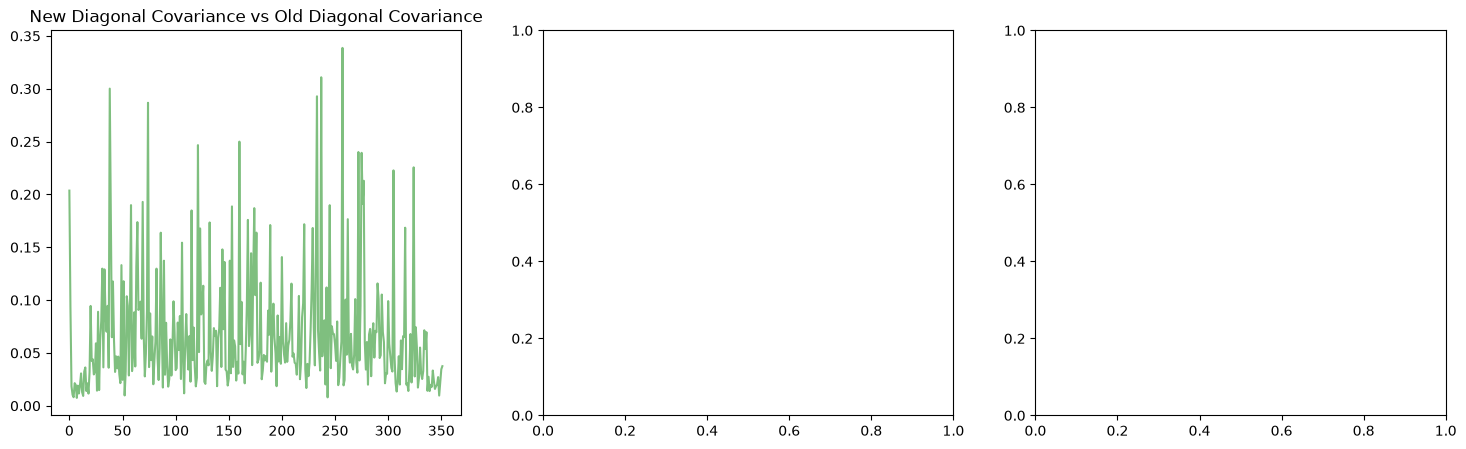

In [3]:
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss


# Import the custom package you generated
from Better_HMC import HMCSampler
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)


num_dimensions = 250
num_data = 100
noise_magnitude_on_each_point = 0.1
num_fourier_entries = 350
total_length = 60
dx = total_length/num_dimensions
fixed_points_linspace = jnp.arange(num_dimensions)*dx + dx/2
full_fourier_period_linspace = jnp.arange(num_fourier_entries)*dx + dx/2
boundary_padding = total_length*(num_fourier_entries/num_dimensions - 1)
omegas = 2 * jnp.pi * jnp.fft.fftfreq(num_fourier_entries, d = dx)
num_fitting_params = 2
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)

hardcoded_logscale = 0
fixed_logvar = 0
hardcoded_lognu = jnp.log(1)

num_overall_steps = 100
burn_in = 10

num_integration_steps = 15
step_size = 0.005

normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logscale, lognu = inference_params
        # Variance is fixed
        logvar = 0
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def rbf_kernel(r, logscale, variance=1.0, jitter=1e-6):
    scale = jnp.exp(logscale)
    result = variance * jnp.exp(-1/2 * (r/scale)**2)
    return jnp.where(r > 0, result, result * (1.0 + jitter))


def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))



def fft_field_rfft(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    half_amp = raw_average_amplitude_data[:size // 2 + 1]
    pos = (noise[1:size // 2] + 1j * noise[size // 2 + 1:size]) / jnp.sqrt(2)
    half_spectrum = jnp.concatenate([noise[0:1], pos, noise[size // 2:size // 2 + 1]]) * half_amp
    y_data = jnp.fft.irfft(half_spectrum, n=size) * normalization_factor
    return y_data[0:num_dimensions]


def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_dimensions]

def fft_field_first_way(noise, inference_params):
    assert noise.shape == omegas.shape
    size = noise.shape[0]
    amplitude_noise_positive_frequencies = (noise[1: size//2] + 1j * noise[size//2 + 1: size])/jnp.sqrt(2)
    amplitude_noise_negative_frequencies = jnp.conj(jnp.flip(amplitude_noise_positive_frequencies))
    amplitude_noise = jnp.concatenate([
        noise[0:1],
        amplitude_noise_positive_frequencies,
        noise[size//2: size//2 + 1],
        amplitude_noise_negative_frequencies
    ])
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    amplitudes = amplitude_noise*raw_average_amplitude_data
    y_data = jnp.real(jnp.fft.ifft(amplitudes)*normalization_factor)
    return y_data[0: num_dimensions]


def fft_field(noise, inference_params):
    return fft_field_hartley(noise, inference_params)


fixed_points_linspace = jnp.linspace(0, total_length, num_dimensions)
full_fourier_period_linspace = jnp.linspace(0, total_length + boundary_padding, num_fourier_entries)
diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2


cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)


k1, k2, k3, k4 = jr.split(jr.key(96), 4)
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=total_length)
y_obs_true = jnp.sin(30*x_obs/10) * jnp.exp(-5*x_obs/10)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)


y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)


xi = jr.normal(k3, shape = num_fourier_entries)
#x_obs = fixed_points_linspace
# If I am hardcoding, the FIRST value is scale and the SECOND value is nu
#y_obs_true = fft_field(xi, (hardcoded_logscale, hardcoded_lognu))
#y_obs_err = jnp.ones_like(y_obs_true)*noise_magnitude_on_each_point
#y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)
#plt.plot(fixed_points_linspace, y_obs_true)


def response_function(xi, inference_params):
    field_points = fft_field(xi, inference_params)
    return jnp.interp(x_obs, fixed_points_linspace, field_points)


def logvarprior(logvar):
    return -0.5*logvar*logvar
def logscaleprior(logscale):
    return -0.5*logscale*logscale
def lognuprior(lognu):
    return -0.5*lognu*lognu
def response(model_values):
    return jnp.interp(x_obs, fixed_points_linspace, model_values)


R = jax.jacobian(response)(fixed_points_linspace)


def negative_logdensity(x):
    logscale = x[0]
    lognu = x[1]
    xi = x[2:]
    inference_params = (logscale, lognu)
    negative_log_p_s = - logscaleprior(logscale) - lognuprior(lognu) + 0.5*xi.T @ xi
    res = y_obs - R @ fft_field(xi, inference_params)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s

num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)
sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps=num_integration_steps,
    step_size=step_size,
    inv_mass_matrix = jnp.eye(num_fourier_entries + num_fitting_params),
    alpha=1.0
)

rng = jr.PRNGKey(4)
initial_coordinates = jnp.zeros(num_fourier_entries + num_fitting_params)

overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates,
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)


logscales = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
overall_position_arr = overall_data_arr[:, 2:]  
logvars = jnp.zeros_like(lognus)
inference_params = (logscales, lognus)


overall_position_arr = jax.vmap(fft_field, in_axes=(0, 0))(
    overall_position_arr, inference_params
)
overall_position_arr = overall_position_arr[:, 0:num_dimensions]


mean_position = overall_position_arr.sum(axis=0)/num_good_samples


vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
#old_cov = jnp.array(np.load('cov_matrix_fitting_three_parameters_matern.npy'))
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_entries + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
#axes[0].plot(timegrid, jnp.diagonal(old_cov), color = "Red", alpha = 0.5)
axes[0].set_title("New Diagonal Covariance vs Old Diagonal Covariance")
#np.save('cov_matrix_fitting_scale_nu_matern.npy', np.asarray(cov))

In [ ]:
## THIS TAKES WAAAAAAYYYYY too long to run! 7/28 Need to fix if I will ever use again

fig, axes = plt.subplots(4, 3, figsize = (18, 20))
print(vars)
print(scales)
for i in range (0, 20):
    axes[0][0].plot(fixed_points_linspace, overall_position_arr[1000*i, :], color = "teal", alpha = 0.2)
    axes[0][0].errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
axes[0][0].plot(fixed_points_linspace, mean_position, color = "orange", alpha = 1)




def log_posterior_density(inference_params):
    logvar, logscale = inference_params
    logprior = logvarprior(logvar) + logscaleprior(logscale)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    jitter = 0
    total_cov_on_data = R @ R.T + cov_data_matrix + jitter
    cho_factor = jsp.linalg.cho_factor(total_cov_on_data)
    solve_val = jsp.linalg.cho_solve(cho_factor, y_obs)
    log_p_data_given_params = -0.5 * (y_obs @ solve_val)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(cho_factor[0])))
    return log_p_data_given_params + logprior - 0.5 * logdet - logprior


def max_log_posterior_density(inference_params):
    log_pd = log_posterior_density(inference_params)
    R = jax.jacobian(lambda xi: response_function(xi, inference_params))(jnp.zeros(num_fourier_entries))
    D = jnp.linalg.inv(jnp.eye(num_fourier_entries) + R.T @ inv_cov_data_matrix @ R)
    _, logdet = jnp.linalg.slogdet(D)
    return log_pd - 0.5*logdet


bins1 = 50
H, xedges, yedges = jnp.histogram2d(logvars, logscales, bins=bins1)


x_centers = jnp.linspace(-3, 3, 50)
y_centers = jnp.linspace(0, 10, 50)


X, Y = jnp.meshgrid(x_centers, y_centers, indexing='ij')


F_vmapped = jax.vmap(lambda lv, ls: log_posterior_density((lv, ls)))
G_vmapped = jax.vmap(lambda lv, ls: max_log_posterior_density((lv, ls)))
Z_flat = F_vmapped(X.ravel(), Y.ravel())
Z2_flat = G_vmapped(X.ravel(), Y.ravel())
Z = Z_flat.reshape(X.shape)  # shape (nx, ny), same layout as H
Z2 = Z2_flat.reshape(X.shape)
Z = jnp.exp(Z - jnp.max(Z))
Z2 = jnp.exp(Z2 - jnp.max(Z2))
Z = Z/jnp.sum(Z)
H = H/jnp.sum(H)


im = axes[0][1].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][1], label='count')


im = axes[3][0].imshow(
    Z.T,
    origin='lower',
    extent=[x_centers[0], x_centers[-1], y_centers[0], y_centers[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[3][0], label='normalized posterior density')


im = axes[3][1].imshow(
    Z2.T,
    origin='lower',
    extent=[x_centers[0], x_centers[-1], y_centers[0], y_centers[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[3][1], label='MAX posterior density')


bins2 = 50  
H, xedges, yedges = jnp.histogram2d(logvars, lognus, bins=bins2)
im = axes[0][2].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][2], label='count')


bins3 = 50
H, xedges, yedges = jnp.histogram2d(logscales, lognus, bins=bins3)
im = axes[1][0].imshow(
    H.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[1][0], label='count')


axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Scale)")
axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Nu)")
axes[1][0].set_xlabel("log(Scale)")
axes[1][0].set_ylabel("log(Nu)")
axes[3][0].set_xlabel("log(Scale)")
axes[3][0].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[1][2].plot(time_arr, scales, color = "Orange")
axes[1][2].set_title("Scale Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")
axes[2][2].set_title("Acceptance Probability Histogram")
axes[2][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')
fig.tight_layout()


[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0.85936513 1.05745416 1.10675569 1.0932021  1.10911634 1.17268855
 0.97386901 0.9434665  0.92187203 0.99260067 1.03083696 1.01571885
 0.9515017  0.89916    0.82171307 0.80959564 0.84691373 0.82285423
 0.83495879 0.86932988 0.8618066  0.77265604 0.7758119  0.80426308
 0.82274607 0.77339597 0.82650399 0.86107523 0.87466428 0.94340216
 1.00791619 1.08839132 0.92383763 1.05472335 1.00140801 1.01053763
 1.14913601 1.14653214 1.30879624 1.30691861 1.31276288 1.43300747
 1.37771334 1.30701769 1.44731095 1.69394397 1.55178617 1.48197678
 1.48026912 1.43848168 1.49943113 1.58957931 1.65890106 1.77258503
 1.77927931 1.83402797 2.02652529 2.0467295  2.25532994 2.33487527
 2.61873034 2.35582634 2.17645511 2.22618194 2.15876598